# DrugReview R1 — ALBERT Multi-Task Aspect Model (Efficacy + Safety)

One shared **ALBERT** backbone with two 3-class aspect heads (`ai_efficacy`, `ai_safety`). One of **four parallel notebooks** = 2 cohorts x {without, with} metadata.

Conventions follow the canonical Manuscript 3 DrugReview pipeline (`NLP-LLM-Evaluation/Manuscript3/03_Hard_Label_Primary/DrugReview_Aspect_*`): GroupShuffleSplit (rs=42) on review text, **metadata textualized into `model_text`** for the DL model, balanced-weighted cross-entropy, AutoTokenizer, FP16 + OneCycleLR + grad-clip, and classification-report / bootstrap-CI / ROC evaluation.

## 1. Setup

In [ ]:
# @cell:pipinstall
# Colab usually ships torch + transformers. Uncomment if needed:
# !pip install -q transformers

In [ ]:
# @cell:imports
import os, re, gc, json, time, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             roc_auc_score, roc_curve, auc, accuracy_score)
from sklearn.preprocessing import label_binarize
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import OneCycleLR
try:
    from torch.amp import autocast, GradScaler
except Exception:
    from torch.cuda.amp import autocast, GradScaler
from transformers import AutoTokenizer, AlbertModel

warnings.filterwarnings('ignore')

In [ ]:
# @cell:seed
SEED = 2025
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed()
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


## 1.1 Configuration

In [ ]:
# @cell:config
# ============================================================
#  RUN CONFIGURATION  (only cell that differs across the 4 notebooks)
# ============================================================
COHORT       = "heterogeneous"          # mood_anxiety | heterogeneous
USE_METADATA = False      # False = review only | True = metadata textualized into model_text
RUN_ID       = "T53_heterogeneous_without_metadata"
CSV_NAME     = "drugsCom_generalized_with_ai_labels_mini.csv"

# ---- Aspect heads: joint efficacy + safety, 3-class each ----
ASPECT_NAMES       = ["ai_efficacy", "ai_safety"]
ASPECT_CLASSES     = ["NEGATIVE", "NEUTRAL", "POSITIVE"]
NUM_ASPECT_CLASSES = len(ASPECT_CLASSES)
ASPECT_LABEL_MAP   = {v: i for i, v in enumerate(ASPECT_CLASSES)}

TEXT_COLUMN0 = "review"       # raw review column
ALBERT_MODEL_NAME = "albert-base-v2"

# ---- Training (Manuscript 3 canonical) ----
MAX_TOKEN_LENGTH = 200
BATCH_SIZE       = 128
N_ITERATIONS     = 10
PATIENCE         = 3
RANDOM_STATE     = 42          # GroupShuffleSplit seed
MAX_GRAD_NORM    = 1.0
RETRAIN          = True

USE_FP16       = torch.cuda.is_available()
TORCH_COMPILE_OK = hasattr(torch, "compile")

# ---- Paths: one experiment folder holds data/ and outputs/ ----
EXPERIMENT_ROOT = Path("./R1/T53_heterogeneous_without_metadata")
DATA_PATH   = EXPERIMENT_ROOT / "data" / CSV_NAME
OUTPUT_PATH = EXPERIMENT_ROOT / "outputs"
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

def resolve_data_path():      # path is fixed; kept so the load cell runs unchanged
    return DATA_PATH

print("COHORT       =", COHORT)
print("USE_METADATA =", USE_METADATA)
print("ASPECTS      =", ASPECT_NAMES)
print("DATA_PATH    =", DATA_PATH)
print("OUTPUT_PATH  =", OUTPUT_PATH)


COHORT       = heterogeneous
USE_METADATA = False
ASPECTS      = ['ai_efficacy', 'ai_safety']
DATA_PATH    = ./R1/T53_heterogeneous_without_metadata/data/drugsCom_generalized_with_ai_labels_mini.csv
OUTPUT_PATH  = ./R1/T53_heterogeneous_without_metadata/outputs


## 1.2 Mount Drive & load data

In [ ]:
# @cell:mount
import os
if os.path.ismount("/content/drive"):
    # Already mounted, skip
    pass
else:
    !fusermount -u /content/drive 2>/dev/null
    # [sanitized] removed destructive Drive wipe
    from google.colab import drive
    drive.mount("/content/drive/", force_remount=True)

Mounted at /content/drive/


In [ ]:
# @cell:load
DATA_PATH = resolve_data_path()
df_raw = pd.read_csv(DATA_PATH)
print(f'Loaded {len(df_raw):,} rows from {DATA_PATH}')
df_raw.head()

Loaded 28,755 rows from ./R1/T53_heterogeneous_without_metadata/data/drugsCom_generalized_with_ai_labels_mini.csv


,uniqueID,drugName,condition,review,rating,date,usefulCount,condition_clean,sentiment_5,ai_rating_10,ai_sentiment_5,ai_efficacy,ai_safety,ai_raw_json_mini,ai_prob_very_negative,ai_prob_negative,ai_prob_neutral,ai_prob_positive,ai_prob_very_positive
0,198878,Depo-Provera,Abnormal Uterine Bleeding,"""Had my daughter in September. I bled for 4 we...",1,5-Nov-16,12,Abnormal Uterine Bleeding,very_negative,2.0,VERY_NEGATIVE,NEGATIVE,NEGATIVE,"[\n {\n ""index"": 0,\n ""ai_rat...",0.6,0.3,0.1,0.0,0.0
1,167406,Levonorgestrel,Abnormal Uterine Bleeding,"""I am a 45, &amp; never pregnant (my husband o...",2,14-Mar-16,24,Abnormal Uterine Bleeding,very_negative,2.0,VERY_NEGATIVE,NEGATIVE,NEGATIVE,"[\n {\n ""index"": 0,\n ""ai_rat...",0.5,0.4,0.1,0.0,0.0
2,13998,Megestrol,Abnormal Uterine Bleeding,"""About two weeks ago I had to be hospitalized ...",10,22-Mar-17,8,Abnormal Uterine Bleeding,very_positive,8.0,POSITIVE,POSITIVE,POSITIVE,"[\n {\n ""index"": 0,\n ""ai_rat...",0.0,0.0,0.1,0.4,0.5
3,198705,Depo-Provera,Abnormal Uterine Bleeding,"""I started my first Depo shot in July of 2016 ...",1,31-Jan-17,2,Abnormal Uterine Bleeding,very_negative,1.0,VERY_NEGATIVE,NEGATIVE,NEGATIVE,"[\n {\n ""index"": 0,\n ""ai_rat...",0.7,0.2,0.1,0.0,0.0
4,44046,Ethinyl estradiol / norgestimate,Abnormal Uterine Bleeding,"""I&#039;ve been taking Tri-Sprintec for almost...",8,10-Jan-12,3,Abnormal Uterine Bleeding,positive,6.0,NEUTRAL,POSITIVE,NEUTRAL,"[\n {\n ""index"": 0,\n ""ai_rat...",0.0,0.2,0.2,0.4,0.2


## 2. Build model text (metadata textualized for the DL model) & clean

In [ ]:
# @cell:modeltext
def normalize_meta(series):
    return (series.fillna('').astype(str).str.strip().str.lower()
            .str.replace(r'\s+', ' ', regex=True))

df = df_raw.copy()
df['drug_norm'] = normalize_meta(df['drugName']) if 'drugName' in df.columns else ''
if 'condition_clean' in df.columns:
    _cond = df['condition_clean'].where(df['condition_clean'].notna(), df.get('condition'))
else:
    _cond = df.get('condition')
df['condition_norm'] = normalize_meta(_cond) if _cond is not None else ''
df['useful_num'] = pd.to_numeric(df.get('usefulCount'), errors='coerce').fillna(0).astype(int)

# DL convention (Manuscript 3): textualize metadata into the input for the 'with metadata' runs;
# text-only runs feed the raw review. Field markers ([DRUG]/[COND]/[USEFUL]/[TEXT]) become
# plain marker words after clean_text strips brackets.
def build_model_text(r):
    return (f"[DRUG] {r['drug_norm']} [COND] {r['condition_norm']} "
            f"[USEFUL] {r['useful_num']} [TEXT] {r[TEXT_COLUMN0]}")

if USE_METADATA:
    df['model_text'] = df.apply(build_model_text, axis=1)
else:
    df['model_text'] = df[TEXT_COLUMN0].fillna('').astype(str)
print('Example model_text:\n', df['model_text'].iloc[0][:200])

Example model_text:
 "Had my daughter in September. I bled for 4 weeks after my delivery. At my PP visit my doctor suggested the depo shot. She mentioned I may have some slight break through bleeding. She recommended the 


In [ ]:
# @cell:clean
def clean_text(text):
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = re.sub(r'http\S+', ' urltoken ', text)
    text = re.sub(r'@\w+', ' usertoken ', text)
    text = re.sub(r'#(\w+)', r' hashtag_\1 ', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['text_clean'] = df['model_text'].apply(clean_text)
# review-level group key (never let the same review span splits)
df['group_key'] = (df[TEXT_COLUMN0].fillna('').astype(str).str.lower()
                   .str.replace(r'\s+', ' ', regex=True).str.strip())
print('Cleaned', len(df), 'rows')

Cleaned 28755 rows


In [ ]:
# @cell:labels
print('Aspect label distributions:')
for asp in ASPECT_NAMES:
    if asp not in df.columns:
        raise ValueError(f'Missing aspect column: {asp}')
    df[asp] = df[asp].astype(str).str.upper().str.strip()
    df[asp] = df[asp].replace({'VERY_POSITIVE': 'POSITIVE', 'VERY_NEGATIVE': 'NEGATIVE'})
    bad = ~df[asp].isin(ASPECT_CLASSES)
    if bad.any():
        print(f'  {asp}: {int(bad.sum())} invalid -> NEUTRAL')
        df.loc[bad, asp] = 'NEUTRAL'
    df[f'{asp}_idx'] = df[asp].map(ASPECT_LABEL_MAP).astype(np.int64)
    print(f'  {asp}: {df[asp].value_counts().to_dict()}')

Aspect label distributions:
  ai_efficacy: {'POSITIVE': 16363, 'NEGATIVE': 9213, 'NEUTRAL': 3179}
  ai_safety: {'NEGATIVE': 12125, 'NEUTRAL': 9702, 'POSITIVE': 6928}


## 2.1 Group split (60 / 20 / 20, rs=42) — no review leaks across splits

In [ ]:
# @cell:split
groups  = df['group_key'].to_numpy()
y_strat = df[f'{ASPECT_NAMES[0]}_idx'].to_numpy()

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(gss1.split(df, y_strat, groups=groups))
split = np.array(['train'] * len(df), dtype=object)
split[test_idx] = 'test'

df_tv = df.iloc[trainval_idx].reset_index(drop=True)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
_tr, _va = next(gss2.split(df_tv, df_tv[f'{ASPECT_NAMES[0]}_idx'], groups=df_tv['group_key']))
split[trainval_idx[_va]] = 'val'
df['split'] = split

print('Split counts:'); print(df['split'].value_counts())
n_leak = int((df.groupby('group_key')['split'].nunique() > 1).sum())
assert n_leak == 0, f'{n_leak} review groups leak across splits!'
print('Group-split leakage check passed (0 reviews span splits).')

Split counts:
split
train    17289
val       5752
test      5714
Name: count, dtype: int64
Group-split leakage check passed (0 reviews span splits).


In [ ]:
# @cell:splitframes
df_train = df[df.split == 'train'].reset_index(drop=True)
df_val   = df[df.split == 'val'].reset_index(drop=True)
df_test  = df[df.split == 'test'].reset_index(drop=True)

train_texts = df_train['text_clean'].tolist()
val_texts   = df_val['text_clean'].tolist()
test_texts  = df_test['text_clean'].tolist()

y_train = {a: df_train[f'{a}_idx'].to_numpy() for a in ASPECT_NAMES}
y_val   = {a: df_val[f'{a}_idx'].to_numpy()   for a in ASPECT_NAMES}
y_test  = {a: df_test[f'{a}_idx'].to_numpy()  for a in ASPECT_NAMES}

# Balanced class weights per aspect (Manuscript 3 DL convention)
aspect_weights = {}
for a in ASPECT_NAMES:
    uniq = np.unique(y_train[a])
    w = compute_class_weight('balanced', classes=uniq, y=y_train[a])
    full = np.ones(NUM_ASPECT_CLASSES, dtype=np.float32)
    for cid, wi in zip(uniq, w):
        full[cid] = wi
    aspect_weights[a] = torch.tensor(full, dtype=torch.float32).to(DEVICE)
    print(a, 'class weights:', full.round(3))
print('Train/Val/Test:', len(df_train), len(df_val), len(df_test))

ai_efficacy class weights: [1.038 2.997 0.587]
ai_safety class weights: [0.789 0.994 1.376]
Train/Val/Test: 17289 5752 5714


## 3. Tokenize, dataset & ALBERT multi-task model

In [ ]:
# @cell:dataset
tokenizer = AutoTokenizer.from_pretrained(ALBERT_MODEL_NAME)

def batch_tokenize(texts, max_len=MAX_TOKEN_LENGTH, chunk=512):
    ids, masks = [], []
    for i in range(0, len(texts), chunk):
        enc = tokenizer([str(t) for t in texts[i:i+chunk]], max_length=max_len,
                        truncation=True, padding='max_length', return_tensors='pt')
        ids.append(enc['input_ids']); masks.append(enc['attention_mask'])
    return torch.cat(ids), torch.cat(masks)

class AspectDataset(Dataset):
    def __init__(self, input_ids, masks, labels):
        self.input_ids = input_ids; self.masks = masks
        self.labels = {a: torch.tensor(np.asarray(v, dtype=np.int64)) for a, v in labels.items()}
    def __len__(self):
        return self.input_ids.shape[0]
    def __getitem__(self, i):
        item = {'input_ids': self.input_ids[i], 'attention_mask': self.masks[i]}
        for a in ASPECT_NAMES:
            item[f'{a}_label'] = self.labels[a][i]
        return item

print('Tokenizing...')
tr_ids, tr_m = batch_tokenize(train_texts)
va_ids, va_m = batch_tokenize(val_texts)
te_ids, te_m = batch_tokenize(test_texts)

loader_kw = dict(batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
train_loader = DataLoader(AspectDataset(tr_ids, tr_m, y_train), shuffle=True,  **loader_kw)
val_loader   = DataLoader(AspectDataset(va_ids, va_m, y_val),   shuffle=False, **loader_kw)
test_loader  = DataLoader(AspectDataset(te_ids, te_m, y_test),  shuffle=False, **loader_kw)
print('Loaders ready.')

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

Tokenizing...
Loaders ready.


In [ ]:
# @cell:model
class AspectALBERT(nn.Module):
    """Shared ALBERT backbone ([CLS]) + one 3-class head per aspect."""
    def __init__(self, model_name, dropout=0.1):
        super().__init__()
        self.base = AlbertModel.from_pretrained(model_name)
        hidden = self.base.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.heads = nn.ModuleDict({a: nn.Linear(hidden, NUM_ASPECT_CLASSES) for a in ASPECT_NAMES})
    def forward(self, input_ids, attention_mask):
        out = self.base(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(out.last_hidden_state[:, 0, :])
        return {a: head(cls) for a, head in self.heads.items()}

## 4. Training (FP16 + OneCycleLR + grad-clip; random search)

In [ ]:
# @cell:train
def train_albert(model, train_loader, val_loader, lr=2e-5, max_epochs=6, patience=PATIENCE):
    model.to(DEVICE)
    if TORCH_COMPILE_OK:
        try:
            model = torch.compile(model, mode='reduce-overhead')
        except Exception:
            pass
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    total_steps = max_epochs * max(1, len(train_loader))
    scheduler = OneCycleLR(optimizer, max_lr=lr, total_steps=total_steps, pct_start=0.1)
    criteria = {a: nn.CrossEntropyLoss(weight=aspect_weights[a]) for a in ASPECT_NAMES}
    scaler = GradScaler(enabled=USE_FP16)
    best_f1, best_state, best_ep, stale = -1.0, None, -1, 0
    for epoch in range(1, max_epochs + 1):
        model.train(); losses = []
        for batch in train_loader:
            ids = batch['input_ids'].to(DEVICE, non_blocking=True)
            mask = batch['attention_mask'].to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast('cuda', enabled=USE_FP16):
                logits = model(ids, mask)
                loss = sum(criteria[a](logits[a], batch[f'{a}_label'].to(DEVICE)) for a in ASPECT_NAMES)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer); scaler.update(); scheduler.step()
            losses.append(loss.item())
        model.eval(); vt = {a: [] for a in ASPECT_NAMES}; vp = {a: [] for a in ASPECT_NAMES}
        with torch.no_grad():
            for batch in val_loader:
                ids = batch['input_ids'].to(DEVICE, non_blocking=True)
                mask = batch['attention_mask'].to(DEVICE, non_blocking=True)
                with autocast('cuda', enabled=USE_FP16):
                    logits = model(ids, mask)
                for a in ASPECT_NAMES:
                    vp[a].extend(logits[a].float().argmax(1).cpu().numpy())
                    vt[a].extend(batch[f'{a}_label'].numpy())
        f1s = {a: f1_score(vt[a], vp[a], average='weighted') for a in ASPECT_NAMES}
        mean_f1 = float(np.mean(list(f1s.values())))
        print(f'  epoch {epoch}/{max_epochs} loss={np.mean(losses):.4f} meanF1={mean_f1:.4f} ' +
              ' '.join(f"{a.replace('ai_','')}={f1s[a]:.3f}" for a in ASPECT_NAMES))
        raw = model._orig_mod if hasattr(model, '_orig_mod') else model
        if mean_f1 > best_f1:
            best_f1 = mean_f1
            best_state = {k: v.cpu().clone() for k, v in raw.state_dict().items()}
            best_ep = epoch; stale = 0
        else:
            stale += 1
            if stale >= patience:
                print('  early stop'); break
    raw = model._orig_mod if hasattr(model, '_orig_mod') else model
    if best_state is not None:
        raw.load_state_dict(best_state)
    return best_f1, raw, best_ep

In [ ]:
# @cell:search
MODEL_PATH  = OUTPUT_PATH / 'best_albert_aspect.pth'
PARAMS_PATH = OUTPUT_PATH / 'best_albert_aspect_params.json'

if RETRAIN:
    set_seed(); start = time.time()
    space = {'lr': (np.log10(1e-5), np.log10(3e-5)), 'epochs': (4, 10), 'dropout': (0.0, 0.25)}
    best_f1, best_params, best_model = 0.0, None, None
    for it in tqdm(range(N_ITERATIONS), desc=f'ALBERT search [{RUN_ID}]'):
        hp = {'lr': float(10 ** np.random.uniform(*space['lr'])),
              'epochs': int(np.random.randint(*space['epochs'])),
              'dropout': float(np.random.uniform(*space['dropout']))}
        model = AspectALBERT(ALBERT_MODEL_NAME, dropout=hp['dropout'])
        f1v, model, ep = train_albert(model, train_loader, val_loader,
                                      lr=hp['lr'], max_epochs=hp['epochs'])
        if f1v > best_f1:
            best_f1, best_params, best_model = f1v, {**hp, 'best_epoch': ep}, model
            torch.save(model.state_dict(), MODEL_PATH)
        del model; gc.collect(); torch.cuda.empty_cache()
    json.dump(best_params, open(PARAMS_PATH, 'w'), indent=2)
    print(f'Best val mean-F1 = {best_f1:.4f} | params = {best_params} | {time.time()-start:.0f}s')
else:
    best_params = json.load(open(PARAMS_PATH))
    best_model = AspectALBERT(ALBERT_MODEL_NAME, dropout=best_params.get('dropout', 0.1))
    best_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
best_model.to(DEVICE).eval()
print('Best model ready.')

ALBERT search [T53_heterogeneous_without_metadata]:   0%|          | 0/10 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

[transformers] AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.LayerNorm.bias   | UNEXPECTED |  | 
predictions.dense.weight     | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 
predictions.dense.bias       | UNEXPECTED |  | 
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  epoch 1/6 loss=1.8899 meanF1=0.7287 efficacy=0.767 safety=0.690
  epoch 2/6 loss=1.2662 meanF1=0.7525 efficacy=0.823 safety=0.682
  epoch 3/6 loss=1.0309 meanF1=0.7638 efficacy=0.823 safety=0.704
  epoch 4/6 loss=0.8565 meanF1=0.7688 efficacy=0.822 safety=0.715
  epoch 5/6 loss=0.7159 meanF1=0.7747 efficacy=0.822 safety=0.727
  epoch 6/6 loss=0.6444 meanF1=0.7738 efficacy=0.822 safety=0.725


...

[transformers] AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.LayerNorm.bias   | UNEXPECTED |  | 
predictions.dense.weight     | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 
predictions.dense.bias       | UNEXPECTED |  | 
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  epoch 1/6 loss=1.8228 meanF1=0.7024 efficacy=0.739 safety=0.665
  epoch 2/6 loss=1.1843 meanF1=0.7637 efficacy=0.802 safety=0.726
  epoch 3/6 loss=0.9405 meanF1=0.7881 efficacy=0.840 safety=0.737
  epoch 4/6 loss=0.7326 meanF1=0.7908 efficacy=0.846 safety=0.736
  epoch 5/6 loss=0.5662 meanF1=0.7891 efficacy=0.838 safety=0.740
  epoch 6/6 loss=0.4805 meanF1=0.7911 efficacy=0.842 safety=0.740


Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

[transformers] AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.LayerNorm.bias   | UNEXPECTED |  | 
predictions.dense.weight     | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 
predictions.dense.bias       | UNEXPECTED |  | 
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  epoch 1/9 loss=1.9077 meanF1=0.7025 efficacy=0.724 safety=0.681
  epoch 2/9 loss=1.2307 meanF1=0.7477 efficacy=0.773 safety=0.723
  epoch 3/9 loss=0.9874 meanF1=0.7564 efficacy=0.816 safety=0.697
  epoch 4/9 loss=0.7708 meanF1=0.7662 efficacy=0.835 safety=0.697
  epoch 5/9 loss=0.5704 meanF1=0.7800 efficacy=0.838 safety=0.722
  epoch 6/9 loss=0.3827 meanF1=0.7882 efficacy=0.840 safety=0.736
  epoch 7/9 loss=0.2683 meanF1=0.7875 efficacy=0.841 safety=0.734
  epoch 8/9 loss=0.1893 meanF1=0.7879 efficacy=0.842 safety=0.734
  epoch 9/9 loss=0.1535 meanF1=0.7893 efficacy=0.842 safety=0.737
Best val mean-F1 = 0.7911 | params = {'lr': 2.0794564875777272e-05, 'epochs': 6, 'dropout': 0.15520777454277573, 'best_epoch': 6} | 1836s
Best model ready.


## 5. Evaluation (per aspect: report, bootstrap F1 CI, confusion, ROC, macro AUC)

ai_efficacy   (3-class: NEGATIVE / NEUTRAL / POSITIVE)
              precision    recall  f1-score   support

    NEGATIVE     0.8441    0.8557    0.8499      1829
     NEUTRAL     0.4539    0.5574    0.5003       653
    POSITIVE     0.9156    0.8663    0.8903      3232

    accuracy                         0.8276      5714
   macro avg     0.7379    0.7598    0.7468      5714
weighted avg     0.8400    0.8276    0.8328      5714

Accuracy       : 0.8276
Macro F1       : 0.7468
Weighted F1    : 0.8329  95% CI [0.8235, 0.8418]
Macro AUC (OvR): 0.9264  95% CI [0.9200, 0.9325]


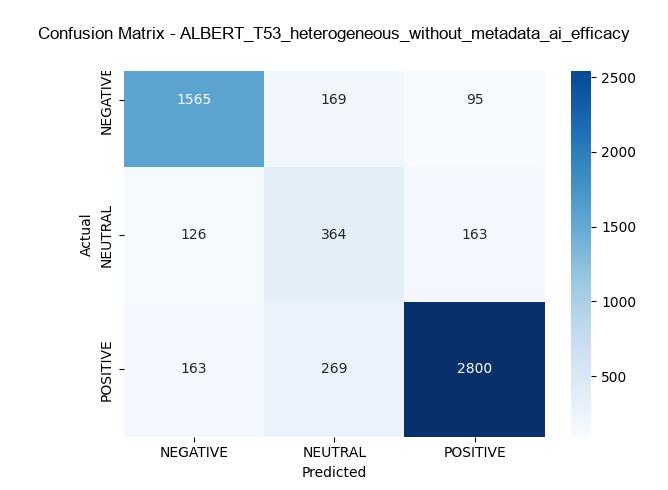

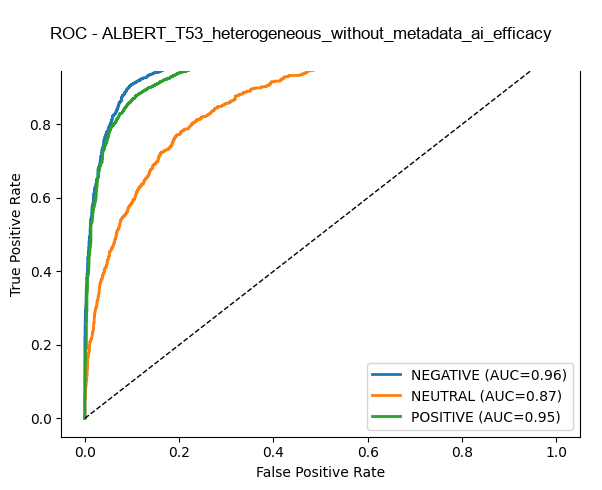

ai_safety   (3-class: NEGATIVE / NEUTRAL / POSITIVE)
              precision    recall  f1-score   support

    NEGATIVE     0.8470    0.8187    0.8326      2400
     NEUTRAL     0.6524    0.6714    0.6618      1957
    POSITIVE     0.7181    0.7303    0.7242      1357

    accuracy                         0.7473      5714
   macro avg     0.7392    0.7402    0.7395      5714
weighted avg     0.7497    0.7473    0.7484      5714

Accuracy       : 0.7473
Macro F1       : 0.7395
Weighted F1    : 0.7484  95% CI [0.7371, 0.7596]
Macro AUC (OvR): 0.8999  95% CI [0.8937, 0.9057]


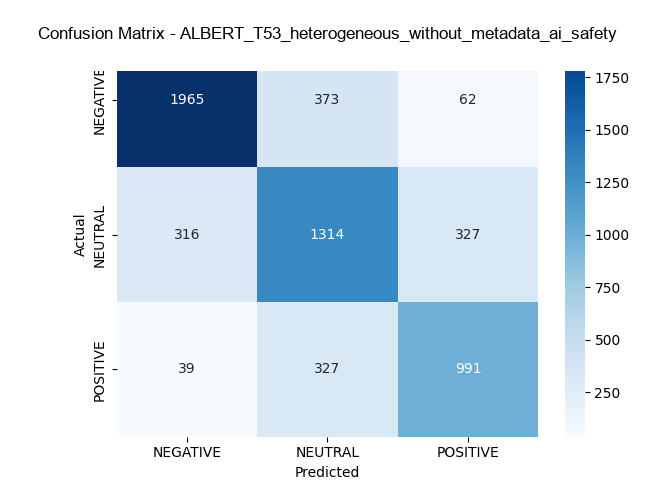

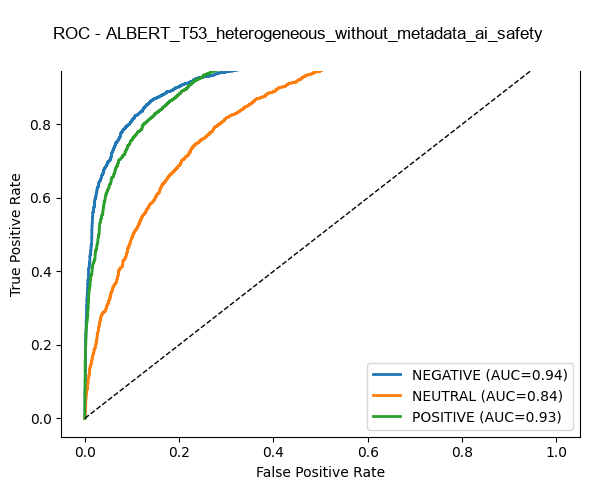

In [ ]:
# @cell:eval
def bootstrap_f1_ci(y_true, y_pred, n=1000, average='weighted'):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred); s = []
    for _ in range(n):
        idx = resample(np.arange(len(y_true)))
        try:
            s.append(f1_score(y_true[idx], y_pred[idx], average=average))
        except ValueError:
            continue
    return (float(np.mean(s)), float(np.percentile(s, 2.5)), float(np.percentile(s, 97.5))) if s else (np.nan,)*3

def bootstrap_auc_ci(y_true, y_prob, n=1000):
    y_true = np.asarray(y_true); y_prob = np.asarray(y_prob); s = []
    for _ in range(n):
        idx = resample(np.arange(len(y_true)))
        try:
            s.append(roc_auc_score(y_true[idx], y_prob[idx], average='macro', multi_class='ovr'))
        except ValueError:
            continue
    return (float(np.mean(s)), float(np.percentile(s, 2.5)), float(np.percentile(s, 97.5))) if s else (np.nan,)*3

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_ASPECT_CLASSES)))
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=ASPECT_CLASSES, yticklabels=ASPECT_CLASSES)
    plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title(f'Confusion Matrix - {title}')
    plt.tight_layout(); plt.savefig(OUTPUT_PATH / f'{title}_confusion_matrix.png', dpi=200); plt.show()

def plot_multiclass_roc(y_true, y_prob, title):
    y_bin = label_binarize(y_true, classes=list(range(NUM_ASPECT_CLASSES)))
    plt.figure(figsize=(6, 5))
    for i, name in enumerate(ASPECT_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc(fpr, tpr):.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'ROC - {title}'); plt.legend(loc='lower right')
    plt.tight_layout(); plt.savefig(OUTPUT_PATH / f'{title}_roc_curve.png', dpi=200); plt.show()

best_model.eval()
logits_all = {a: [] for a in ASPECT_NAMES}; true_all = {a: [] for a in ASPECT_NAMES}
with torch.no_grad():
    for batch in test_loader:
        ids = batch['input_ids'].to(DEVICE, non_blocking=True)
        mask = batch['attention_mask'].to(DEVICE, non_blocking=True)
        with autocast('cuda', enabled=USE_FP16):
            logits = best_model(ids, mask)
        for a in ASPECT_NAMES:
            logits_all[a].append(logits[a].float().cpu().numpy())
            true_all[a].extend(batch[f'{a}_label'].numpy())

results = {}
for a in ASPECT_NAMES:
    lg = np.concatenate(logits_all[a])
    prob = torch.softmax(torch.tensor(lg), dim=1).numpy()
    pred = prob.argmax(1); true = np.asarray(true_all[a])
    print('=' * 58); print(f'{a}   (3-class: NEGATIVE / NEUTRAL / POSITIVE)'); print('=' * 58)
    print(classification_report(true, pred, labels=list(range(NUM_ASPECT_CLASSES)),
                                target_names=ASPECT_CLASSES, digits=4, zero_division=0))
    f1m, f1lo, f1hi = bootstrap_f1_ci(true, pred)
    aucm, auclo, auchi = bootstrap_auc_ci(true, prob)
    print(f'Accuracy       : {accuracy_score(true, pred):.4f}')
    print(f'Macro F1       : {f1_score(true, pred, average="macro", zero_division=0):.4f}')
    print(f'Weighted F1    : {f1m:.4f}  95% CI [{f1lo:.4f}, {f1hi:.4f}]')
    print(f'Macro AUC (OvR): {aucm:.4f}  95% CI [{auclo:.4f}, {auchi:.4f}]')
    plot_confusion_matrix(true, pred, f'ALBERT_{RUN_ID}_{a}')
    plot_multiclass_roc(true, prob, f'ALBERT_{RUN_ID}_{a}')
    results[a] = {'y_true': true, 'y_pred': pred,
                  'accuracy': float(accuracy_score(true, pred)),
                  'macro_f1': float(f1_score(true, pred, average='macro', zero_division=0)),
                  'weighted_f1': f1m, 'f1_ci': (f1lo, f1hi),
                  'macro_auc': aucm, 'auc_ci': (auclo, auchi)}

## 6. Save predictions & summary

In [ ]:
# @cell:save
cols = [c for c in [TEXT_COLUMN0, 'drugName', 'condition', 'usefulCount'] if c in df_test.columns]
out = df_test[cols].copy()
for a in ASPECT_NAMES:
    out[f'{a}_true'] = results[a]['y_true']
    out[f'{a}_pred'] = results[a]['y_pred']
joint = np.ones(len(df_test), dtype=bool)
for a in ASPECT_NAMES:
    joint &= (results[a]['y_true'] == results[a]['y_pred'])
out['joint_correct'] = joint.astype(int)
pred_path = OUTPUT_PATH / 'test_predictions.csv'
out.to_csv(pred_path, index=False)

summary = {
    'run_id': RUN_ID, 'cohort': COHORT, 'use_metadata': bool(USE_METADATA),
    'data_file': CSV_NAME, 'data_path': str(DATA_PATH),
    'n_train': int(len(df_train)), 'n_val': int(len(df_val)), 'n_test': int(len(df_test)),
    'aspects': {a: {'accuracy': results[a]['accuracy'], 'macro_f1': results[a]['macro_f1'],
                    'weighted_f1': results[a]['weighted_f1'],
                    'f1_ci': [results[a]['f1_ci'][0], results[a]['f1_ci'][1]],
                    'macro_auc': results[a]['macro_auc'],
                    'auc_ci': [results[a]['auc_ci'][0], results[a]['auc_ci'][1]]}
                for a in ASPECT_NAMES},
    'joint_exact_match': float(joint.mean()),
}
json.dump(summary, open(OUTPUT_PATH / 'summary.json', 'w'), indent=2)
print(json.dumps(summary, indent=2))
print('Saved predictions ->', pred_path)

{
  "run_id": "T53_heterogeneous_without_metadata",
  "cohort": "heterogeneous",
  "use_metadata": false,
  "data_file": "drugsCom_generalized_with_ai_labels_mini.csv",
  "data_path": "./R1/T53_heterogeneous_without_metadata/data/drugsCom_generalized_with_ai_labels_mini.csv",
  "n_train": 17289,
  "n_val": 5752,
  "n_test": 5714,
  "aspects": {
    "ai_efficacy": {
      "accuracy": 0.827616380819041,
      "macro_f1": 0.746832124867637,
      "weighted_f1": 0.8329314338519818,
      "f1_ci": [
        0.8235088557425942,
        0.841823451801895
      ],
      "macro_auc": 0.9264418747832754,
      "auc_ci": [
        0.920031687253493,
        0.9325309326526702
      ]
    },
    "ai_safety": {
      "accuracy": 0.7472873643682184,
      "macro_f1": 0.7395252280601502,
      "weighted_f1": 0.748425683892108,
      "f1_ci": [
        0.7371205306506128,
        0.7595951804699316
      ],
      "macro_auc": 0.8998840831538377,
      "auc_ci": [
        0.8936844803107533,
        0.